In [2]:
import sys
print(sys.version)
print(sys.executable)

3.13.2 (main, Oct 20 2025, 18:07:39) [Clang 21.0.0git (https:/github.com/llvm/llvm-project 2f05451198e2f222ec66cec489
/home/pyodide/this.program


In [4]:
import micropip
await micropip.install("seaborn")

In [5]:
import seaborn as sns
print("Seaborn installed successfully!")

Seaborn installed successfully!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import os

print(os.getcwd())  # Current folder
print(os.listdir()) # Files in the folder

/drive
['Data_Cleaning_and_Visualization.ipynb.ipynb', 'Untitled.ipynb', 'notebooks', 'README.md', 'data']


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("netflix_titles.csv")

In [13]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
df.shape

(8807, 12)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 447.3+ KB


In [16]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [17]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [18]:
df.drop_duplicates(inplace=True)

print("Duplicates removed!")

Duplicates removed!


In [19]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [20]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

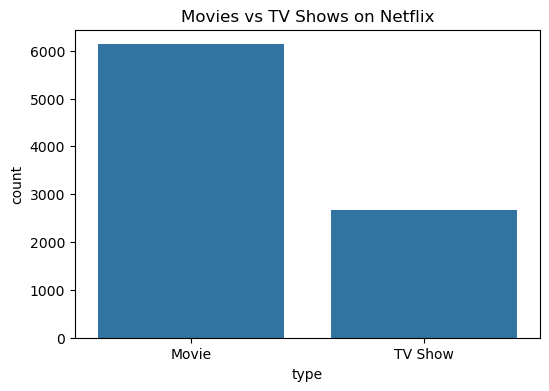

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows on Netflix')
plt.show()

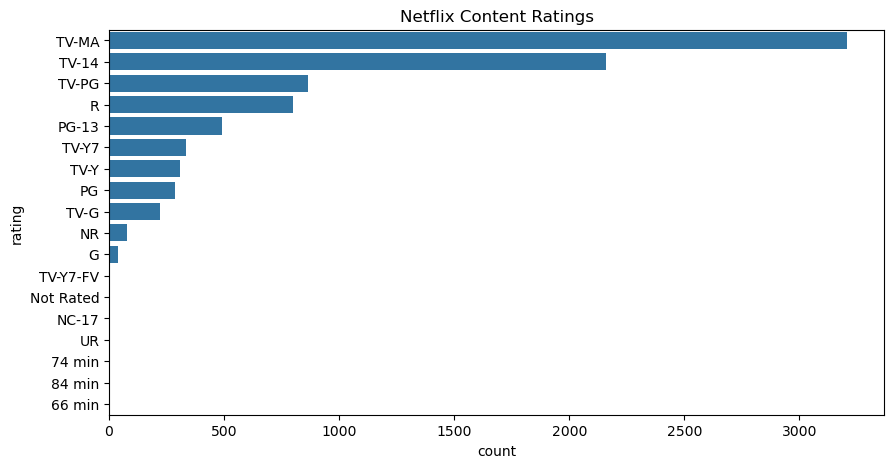

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title('Netflix Content Ratings')
plt.show()

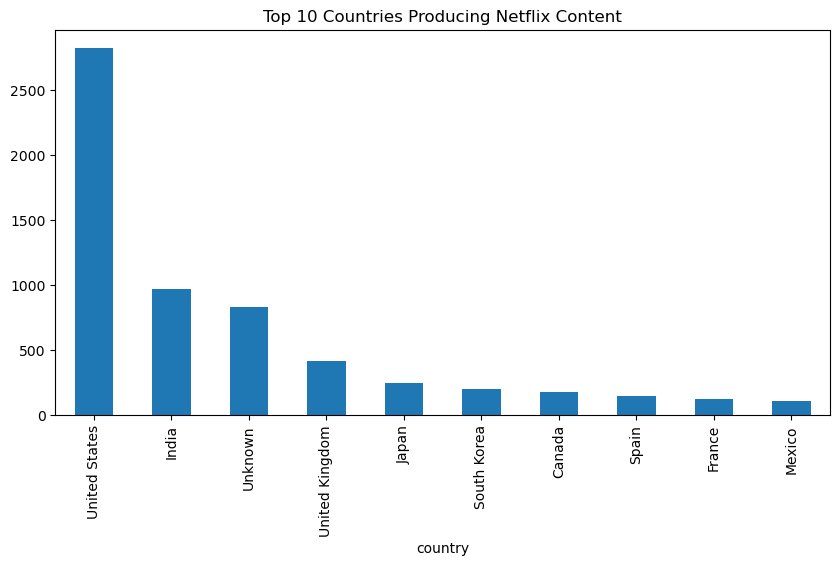

In [23]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries Producing Netflix Content')
plt.show()

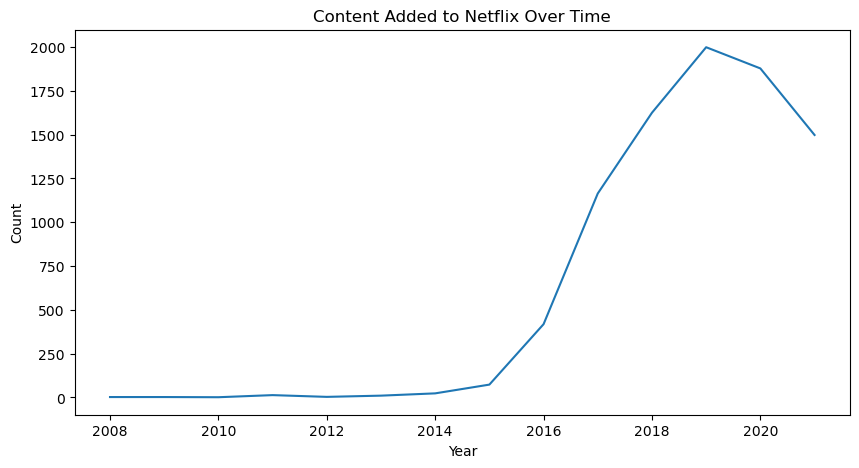

In [24]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot()
plt.title('Content Added to Netflix Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

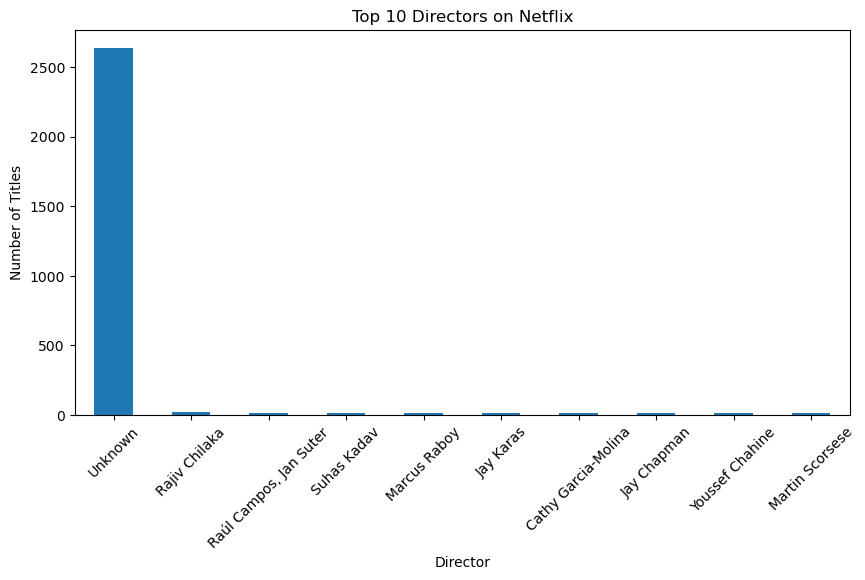

In [25]:
top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_directors.plot(kind='bar')
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

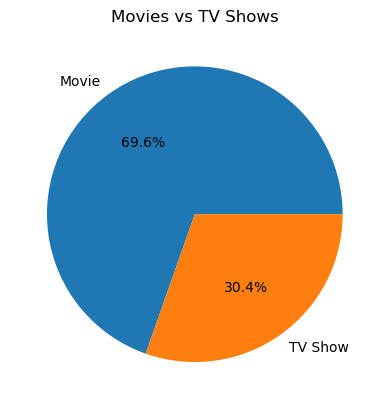

In [26]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows')
plt.ylabel('')
plt.show()

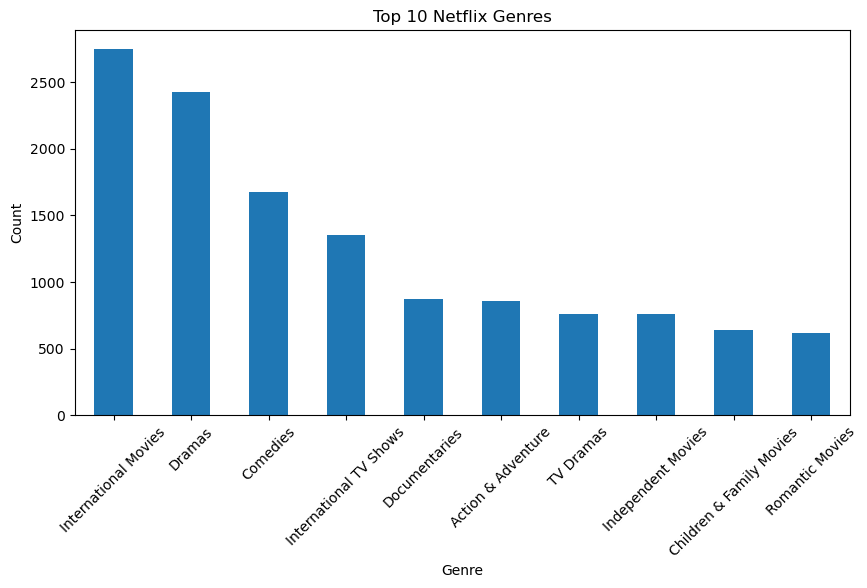

In [27]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

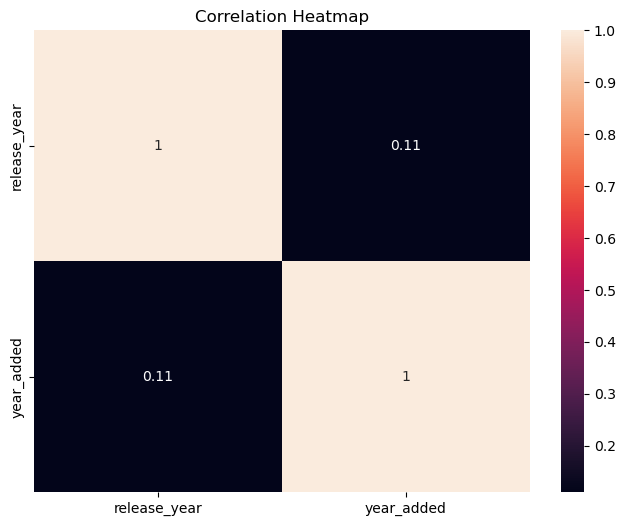

In [28]:
numeric_df = df.select_dtypes(include=['int64','float64'])

if not numeric_df.empty:
    plt.figure(figsize=(8,6))
    sns.heatmap(numeric_df.corr(), annot=True)
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print("No sufficient numeric columns for correlation heatmap.")

In [29]:
df.to_csv('netflix_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
